# Variational Autoencoder Variants and Extensions

The vanilla VAE follows a clear principle: approximate maximum likelihood in a deep latent-variable model by optimizing the ELBO. This principle also exposes the main weaknesses of the model. The **KL term** may over-regularize the **latent channel**, some **latent dimension**s may become inactive, the **aggregate posterior** may fail to match the sampling prior, pixelwise likelihoods may encourage blurry averages, and unconditional generation gives little control over the type of sample produced.

VAE variants modify one of these ingredients while preserving the latent-variable structure. Some variants change the weight or schedule of the **KL term**. Some replace the continuous Gaussian bottleneck with a **discrete codebook**. Some condition the encoder and decoder on labels or other side information.

The discussion has two levels. The theoretical level describes which object changes: the objective, posterior family, prior, latent representation, or conditioning structure. The motivational level explains which vanilla-VAE limitation the change is meant to address. This mirrors the logic of the ELBO derivation: every architectural or objective modification should correspond to a precise modeling pressure.

```{admonition} How to read the variants
:class: note

Each variant changes one pressure in the vanilla ELBO system: the strength of the **KL term**, the schedule of the **information bottleneck**, the type of latent representation, or the conditioning information available to the encoder and decoder.
```

## Shared Setup

All variants below use the same `FashionMNIST` data pipeline and the same convolutional baseline components, so that comparisons remain meaningful. **FID/KID** is postponed to the end, so the real-data features only need to be accumulated once.

In [2]:
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from torchvision import datasets, transforms, utils
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(7)
if device.type == "cuda":
    torch.cuda.manual_seed_all(7)
num_workers = 0
project_root = Path.cwd() if (Path.cwd() / "_config.yml").exists() else Path.cwd().parent
DATA_ROOT = project_root / "data"

# Settings
batch_size = 128
latent_dim = 32
base_channels = 32
lr = 2e-4
epochs = 60

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.FashionMNIST(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
)


In [3]:
class VAE(nn.Module):
    def __init__(self, latent_dim=32, base_channels=32):
        super().__init__()
        # 28x28 -> 14x14 -> 7x7.
        self.encoder = nn.Sequential(
            nn.Conv2d(1, base_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.SiLU(),
            nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels * 2),
            nn.SiLU(),
            nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_channels * 4),
            nn.SiLU(),
            nn.Flatten(),
        )
        encoded_dim = base_channels * 4 * 7 * 7
        self.mu_head = nn.Linear(encoded_dim, latent_dim)
        self.logvar_head = nn.Linear(encoded_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, encoded_dim),
            nn.SiLU(),
            nn.Unflatten(1, (base_channels * 4, 7, 7)),
            nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels * 2),
            nn.SiLU(),
            nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.SiLU(),
            nn.Conv2d(base_channels, 1, kernel_size=3, padding=1),
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.mu_head(h)
        logvar = self.logvar_head(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        # Sample through parameter-free noise so gradients can flow to mu/logvar.
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        logits = self.decoder(z)
        return logits

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z)
        return logits, mu, logvar


model = VAE(latent_dim=latent_dim, base_channels=base_channels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [4]:
@torch.no_grad()
def show_reconstructions(model, loader, device, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)
    logits, _, _ = model(x)
    # Sigmoid is only for visualization; training used logits directly.
    recon = torch.sigmoid(logits).view(-1, 1, 28, 28)

    grid = torch.cat([x.cpu(), recon.cpu()], dim=0)
    image = utils.make_grid(grid, nrow=n, pad_value=1.0)
    plt.figure(figsize=(1.5 * n, 3.0))
    plt.imshow(image.permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.show()


@torch.no_grad()
def show_samples(model, device, n=16):
    model.eval()
    z = torch.randn(n, latent_dim, device=device)
    logits = model.decode(z)
    samples = torch.sigmoid(logits).view(-1, 1, 28, 28).cpu()
    image = utils.make_grid(samples, nrow=4, pad_value=1.0)
    plt.figure(figsize=(6, 6))
    plt.imshow(image.permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.show()

In [5]:
@torch.no_grad()
def interpolate(model, loader, device, steps=8):
    model.eval()
    x, _ = next(iter(loader))
    x0 = x[0:1].to(device)
    x1 = x[1:2].to(device)

    # Interpolate between posterior means to visualize latent geometry.
    mu0, _ = model.encode(x0)
    mu1, _ = model.encode(x1)

    alphas = torch.linspace(0, 1, steps, device=device).view(-1, 1)
    z = (1 - alphas) * mu0 + alphas * mu1
    logits = model.decode(z)
    images = torch.sigmoid(logits).view(-1, 1, 28, 28).cpu()

    grid = utils.make_grid(images, nrow=steps, pad_value=1.0)
    plt.figure(figsize=(1.7 * steps, 2.5))
    plt.imshow(grid.permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.show()


## Controlling Information Flow: Beta-VAE, KL Annealing, and Free Bits

The first family of VAE variants does not change the architecture in a dramatic way. It changes the pressure exerted by the objective on the **latent channel**. This is a good starting point because many practical VAE failures are not caused by an encoder or decoder that is obviously too small. They are caused by an objective that asks the model to satisfy two competing goals at the same time: reconstruct the data accurately and keep the approximate posterior close to a simple prior.

For a vanilla VAE, the objective minimized during training is the **negative ELBO**,

$$
\mathcal{L}_{VAE}(\boldsymbol{x})
=
\mathbb{E}_{q_\phi(\boldsymbol{z}|\boldsymbol{x})}
\left[-\log p_\theta(\boldsymbol{x}|\boldsymbol{z})\right]
+
D_{KL}\left(q_\phi(\boldsymbol{z}|\boldsymbol{x}) \| p(\boldsymbol{z})\right).
$$

The first term is a distortion term: it measures how well the latent code reconstructs the input. The second term is a rate term: it measures how much information the encoder is allowed to transmit through the latent variable, relative to the prior. This terminology is useful because it makes the main tradeoff explicit. A model that uses a large rate can reconstruct well, but the posterior may become difficult to sample from using the simple prior. A model that uses a very small rate is easy to sample from, but the decoder receives little information about the input.

`beta-VAE` {cite}`higgins2017betavae` modifies this tradeoff by introducing a scalar multiplier:

$$
\mathcal{L}_{\beta\text{-}VAE}(\boldsymbol{x})
=
\mathbb{E}_{q_\phi(\boldsymbol{z}|\boldsymbol{x})}
\left[-\log p_\theta(\boldsymbol{x}|\boldsymbol{z})\right]
+
\beta\,
D_{KL}\left(q_\phi(\boldsymbol{z}|\boldsymbol{x}) \| p(\boldsymbol{z})\right).
$$

When $\beta>1$, the model pays a larger price for using information in the latent code. This can encourage a more compact representation and, in some settings, more interpretable latent factors. However, it can also damage reconstruction quality and increase the risk of inactive dimensions. When $\beta<1$, the model is allowed to use the latent variable more freely. **Reconstruction**s often improve, but samples drawn from the prior can become worse because the **aggregate posterior** may drift farther from the prior. Therefore, `beta` is not a quality knob that can simply be increased. It is a **rate-control knob**.

```{figure} ../assets/images/beta_VAE.png
:width: 66%
:align: center

The effect of $\beta$ in $\beta$-VAE.
```

The theoretical perspective is that `beta-VAE` replaces likelihood maximization with a constrained or Lagrangian view of representation learning. Informally, one can read the objective as asking for small distortion subject to a limited information budget. Increasing `beta` tightens the budget. Decreasing `beta` relaxes it. The motivational perspective is simpler: the vanilla VAE has one fixed compromise between reconstruction and regularization, but different datasets and decoders need different compromises. `beta-VAE` gives us a way to move that compromise deliberately.

The limitation is that a fixed value of `beta` applies the same pressure throughout training. Early in training, the decoder and encoder do not yet know how to communicate. If the **KL term** is too strong at this stage, the easiest solution is to make the posterior close to the prior for every input. Once this happens, the decoder learns to work without the latent code, and the encoder may never recover. This is one route to **posterior collapse**.

In implementation terms, `beta` is the cleanest control knob in the VAE family. It does not change the latent-variable model or the encoder architecture. It changes only the relative strength of the **KL term**. The loss below therefore makes the rate-distortion interpretation visible in code.

```{admonition} Rate and distortion
:class: tip

Increasing $\beta$ usually improves latent regularity at the cost of reconstruction detail. Decreasing $\beta$ usually improves reconstruction at the cost of prior-sampling reliability.
```

In [6]:
def kl_per_sample(mu, logvar):
    # Keep the per-sample KL so we can reweight or threshold it flexibly.
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)


def beta_vae_loss(x, logits, mu, logvar, beta=1.0, free_bits=0.0):
    reconstruction = F.binary_cross_entropy_with_logits(
        logits,
        x,
        reduction="sum",
    )
    kl_values = kl_per_sample(mu, logvar)
    if free_bits > 0.0:
        # Each sample is allowed to use a small amount of KL capacity for free.
        kl_values = torch.clamp(kl_values, min=free_bits)
    kl = kl_values.sum()
    loss = reconstruction + beta * kl
    return loss, reconstruction, kl


def linear_beta_schedule(epoch, total_epochs, start=0.0, stop=1.0, warmup_fraction=0.4):
    warmup_epochs = max(1, int(total_epochs * warmup_fraction))
    if epoch >= warmup_epochs:
        return stop
    progress = epoch / warmup_epochs
    return start + progress * (stop - start)

In [7]:
def train_beta_vae_epoch(model, loader, optimizer, device, beta=1.0):
    model.train()
    total_loss = 0.0
    total_kl = 0.0
    for x, _ in tqdm(loader, desc="beta-VAE train", leave=False):
        x = x.to(device)
        optimizer.zero_grad()
        logits, mu, logvar = model(x)
        loss, _, kl = beta_vae_loss(x, logits, mu, logvar, beta=beta)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_kl += kl.item()
    n = len(loader.dataset)
    return {"loss": total_loss / n, "kl": total_kl / n}


@torch.no_grad()
def evaluate_beta_vae(model, loader, device, beta=1.0):
    model.eval()
    total_loss = 0.0
    total_kl = 0.0
    for x, _ in loader:
        x = x.to(device)
        logits, mu, logvar = model(x)
        loss, _, kl = beta_vae_loss(x, logits, mu, logvar, beta=beta)
        total_loss += loss.item()
        total_kl += kl.item()
    n = len(loader.dataset)
    return {"loss": total_loss / n, "kl": total_kl / n}


beta_model = VAE(latent_dim=latent_dim, base_channels=base_channels).to(device)
beta_optimizer = torch.optim.Adam(beta_model.parameters(), lr=lr)
beta_history = {"train_loss": [], "val_loss": [], "kl": []}
beta_epochs = 50
beta_value = 4.0

for epoch in tqdm(range(beta_epochs), desc="beta-VAE epochs"):
    train_stats = train_beta_vae_epoch(beta_model, train_loader, beta_optimizer, device, beta=beta_value)
    val_stats = evaluate_beta_vae(beta_model, test_loader, device, beta=beta_value)
    beta_history["train_loss"].append(train_stats["loss"])
    beta_history["val_loss"].append(val_stats["loss"])
    beta_history["kl"].append(train_stats["kl"])
    print(
        f"Epoch {epoch + 1:02d} | beta={beta_value:.1f} | "
        f"train loss: {train_stats['loss']:.4f} | "
        f"val loss: {val_stats['loss']:.4f} | "
        f"KL: {train_stats['kl']:.4f}"
    )


beta-VAE epochs:   0%|          | 0/50 [00:00<?, ?it/s]

beta-VAE train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 01 | beta=4.0 | train loss: 325.6506 | val loss: 292.6421 | KL: 6.8962


beta-VAE train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 02 | beta=4.0 | train loss: 286.8193 | val loss: 284.9199 | KL: 7.1615


...

Epoch 48 | beta=4.0 | train loss: 268.3688 | val loss: 269.9342 | KL: 7.1884


beta-VAE train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 49 | beta=4.0 | train loss: 268.2670 | val loss: 269.5371 | KL: 7.1935


beta-VAE train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 50 | beta=4.0 | train loss: 268.2067 | val loss: 269.9617 | KL: 7.1944


A useful qualitative comparison is obtained by placing this run next to the vanilla VAE. Larger `beta` values often produce a more organized **latent space** but softer reconstructions. Smaller `beta` values often improve reconstruction while making prior sampling less reliable. The visible samples are therefore an empirical picture of the same **rate-distortion tradeoff** described by the objective.

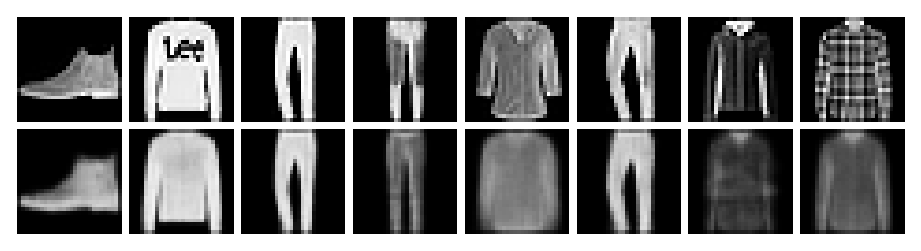

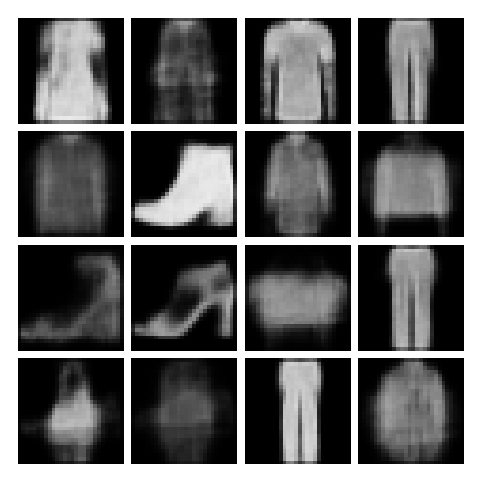

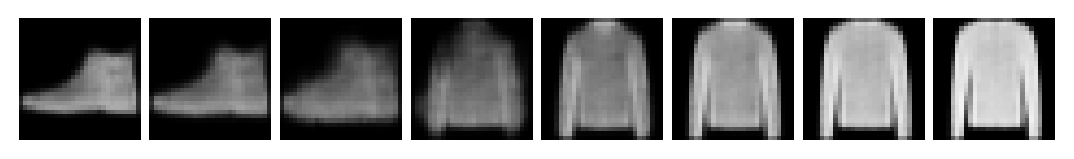

In [8]:
show_reconstructions(beta_model, test_loader, device)
show_samples(beta_model, device)
interpolate(beta_model, test_loader, device)

If the value of $\beta$ is set too high, the $D_{KL}$ term dominates and $q_\phi(\boldsymbol{z} | \boldsymbol{x})$ becomes uninformative, causing **mode collapse**.

beta-VAE train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 01 | beta=100.0 | train loss: 408.9631 | val loss: 388.7563 | KL: 0.0936


beta-VAE train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 02 | beta=100.0 | train loss: 387.0263 | val loss: 387.5785 | KL: 0.0155


beta-VAE train:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 48 | beta=100.0 | train loss: 384.5634 | val loss: 385.5393 | KL: 0.0023


beta-VAE train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 49 | beta=100.0 | train loss: 384.5199 | val loss: 385.2124 | KL: 0.0022


beta-VAE train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 50 | beta=100.0 | train loss: 384.5532 | val loss: 385.2287 | KL: 0.0021


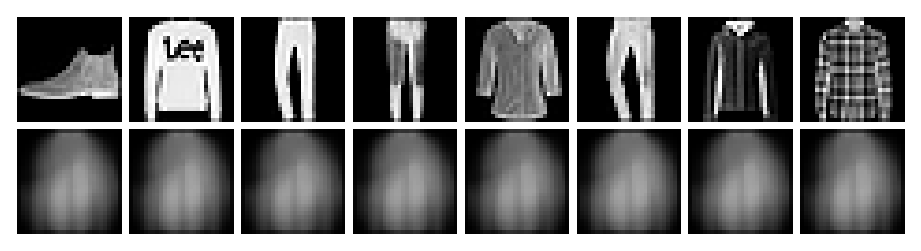

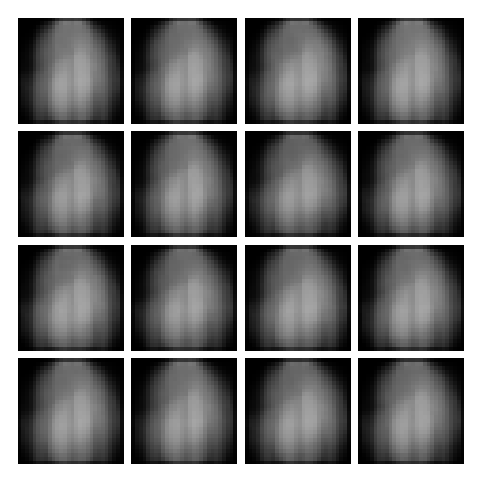

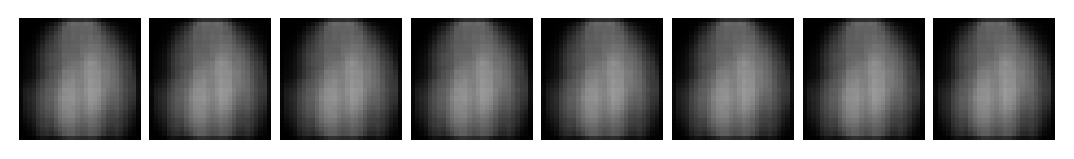

In [9]:
beta_collapse_model = VAE(latent_dim=latent_dim, base_channels=base_channels).to(device)
beta_optimizer = torch.optim.Adam(beta_collapse_model.parameters(), lr=lr)
beta_collapse_history = {"train_loss": [], "val_loss": [], "kl": []}
beta_epochs = 50
beta_value = 100.0

for epoch in range(beta_epochs):
    train_stats = train_beta_vae_epoch(beta_collapse_model, train_loader, beta_optimizer, device, beta=beta_value)
    val_stats = evaluate_beta_vae(beta_collapse_model, test_loader, device, beta=beta_value)
    beta_collapse_history["train_loss"].append(train_stats["loss"])
    beta_collapse_history["val_loss"].append(val_stats["loss"])
    beta_collapse_history["kl"].append(train_stats["kl"])
    print(
        f"Epoch {epoch + 1:02d} | beta={beta_value:.1f} | "
        f"train loss: {train_stats['loss']:.4f} | "
        f"val loss: {val_stats['loss']:.4f} | "
        f"KL: {train_stats['kl']:.4f}"
    )

show_reconstructions(beta_collapse_model, test_loader, device)
show_samples(beta_collapse_model, device)
interpolate(beta_collapse_model, test_loader, device)

### KL Annealing, Free Bits, and Posterior Collapse

**KL annealing** and **free bits** are two attempts to make the information budget dynamic rather than fixed. They are motivated by the observation that the most dangerous moment for **posterior collapse** is often the beginning of training. At that point, the decoder can reduce the reconstruction loss by learning broad regularities of the data, while the encoder is immediately penalized for transmitting information. If the optimizer discovers that ignoring $\boldsymbol{z}$ is a stable solution, the **latent channel** can become inactive before it becomes useful.

**KL annealing** changes the training objective over time:

$$
\mathcal{L}_{anneal}(\boldsymbol{x},t)
=
\mathbb{E}_{q_\phi(\boldsymbol{z}|\boldsymbol{x})}
\left[-\log p_\theta(\boldsymbol{x}|\boldsymbol{z})\right]
+
\beta(t)
D_{KL}\left(q_\phi(\boldsymbol{z}|\boldsymbol{x}) \| p(\boldsymbol{z})\right),
$$

where $\beta(t)$ starts near zero and gradually increases toward its target value. The mechanism is simple but important. At the beginning, the model is encouraged to learn an informative autoencoding channel. Later, the **KL pressure** is increased so that the learned representation becomes compatible with the prior. In motivational terms, **KL annealing** first teaches the model to speak through the latent variable, and only later teaches it to speak economically.

Free bits attack the same problem from a different angle. Instead of globally reducing the KL weight, **free bits** define a minimum amount of information that the model can use without being penalized too aggressively. For a latent vector with coordinate-wise KL contributions, one common form is

$$
\mathcal{L}_{free}(\boldsymbol{x})
=
\mathbb{E}_{q_\phi(\boldsymbol{z}|\boldsymbol{x})}
\left[-\log p_\theta(\boldsymbol{x}|\boldsymbol{z})\right]
+
\sum_{\ell=1}^{L}
\max\left(\lambda,
D_{KL}\left(q_\phi(z_\ell|\boldsymbol{x}) \| p(z_\ell)\right)\right).
$$

The constant $\lambda$ is the number of free nats assigned to each latent component or group of components. Below this threshold, reducing the KL further does not improve the objective. This discourages the optimizer from spending effort on making already-small **KL term**s even smaller. In practical language, **free bits** tell the model: use at least a small amount of capacity before I start charging you for it.

The connection with dead **latent dimension**s is direct. For a **diagonal Gaussian encoder**,

$$
q_\phi(\boldsymbol{z}|\boldsymbol{x})
=
\mathcal{N}\left(
\boldsymbol{\mu}_\phi(\boldsymbol{x}),
\operatorname{diag}(\boldsymbol{\sigma}^2_\phi(\boldsymbol{x}))
\right),
$$

a dimension is inactive when $\mu_{\phi,\ell}(\boldsymbol{x}) \approx 0$ and $\sigma_{\phi,\ell}(\boldsymbol{x}) \approx 1$ for almost all inputs. In that case,

$$
q_\phi(z_\ell|\boldsymbol{x}) \approx p(z_\ell),
$$

so the coordinate carries almost no information about $\boldsymbol{x}$. This is sometimes called a dead or collapsed **latent dimension**. The word collapsed does not mean that the numerical value is constant. It means that the **posterior distribution** for that coordinate is essentially the prior, so sampling that coordinate tells the decoder almost nothing about the input.

```{figure} ../assets/images/dead_dimensions.png
:width: 66%
:align: center

The effect of collapsed **latent dimension**s.
```

**KL annealing** and **free bits** are not guaranteed cures. If the decoder is too powerful, if the **latent dimension**ality is badly chosen, or if the likelihood model rewards averaging, the **latent channel** can still be underused. But these methods make the optimization path less hostile to latent-variable usage. They are also cheap, which makes them important baselines: before introducing a new generative paradigm, one should first understand how far the original VAE can be improved by changing the objective.

In [10]:
annealed_model = VAE(latent_dim=latent_dim, base_channels=base_channels).to(device)
annealed_optimizer = torch.optim.Adam(annealed_model.parameters(), lr=lr)
annealed_history = {"train_loss": [], "val_loss": [], "beta": []}
annealed_epochs = 50
free_bits_value = 0.1

for epoch in tqdm(range(annealed_epochs), desc="annealed VAE epochs"):
    beta_t = linear_beta_schedule(epoch, annealed_epochs, start=0.0, stop=1.0, warmup_fraction=0.4)
    annealed_model.train()
    total_loss = 0.0
    for x, _ in tqdm(train_loader, desc="annealed train", leave=False):
        x = x.to(device)
        annealed_optimizer.zero_grad()
        logits, mu, logvar = annealed_model(x)
        loss, _, _ = beta_vae_loss(x, logits, mu, logvar, beta=beta_t, free_bits=free_bits_value)
        loss.backward()
        annealed_optimizer.step()
        total_loss += loss.item()
    annealed_history["train_loss"].append(total_loss / len(train_loader.dataset))
    annealed_history["beta"].append(beta_t)
    print(f"Epoch {epoch + 1:02d} | beta_t={beta_t:.2f} | train loss: {annealed_history['train_loss'][-1]:.4f}")


annealed VAE epochs:   0%|          | 0/50 [00:00<?, ?it/s]

annealed train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 01 | beta_t=0.00 | train loss: 265.2941


annealed train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 02 | beta_t=0.05 | train loss: 223.2193


...

Epoch 48 | beta_t=1.00 | train loss: 237.5838


annealed train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 49 | beta_t=1.00 | train loss: 237.6048


annealed train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 50 | beta_t=1.00 | train loss: 237.4596


This experiment is conceptually different from the fixed-`beta` run. The question is no longer only how tight the final bottleneck should be. The question is how the bottleneck should be introduced during optimization. A schedule that starts gently and becomes stricter later can preserve latent usage while still ending with a structured **latent space**.

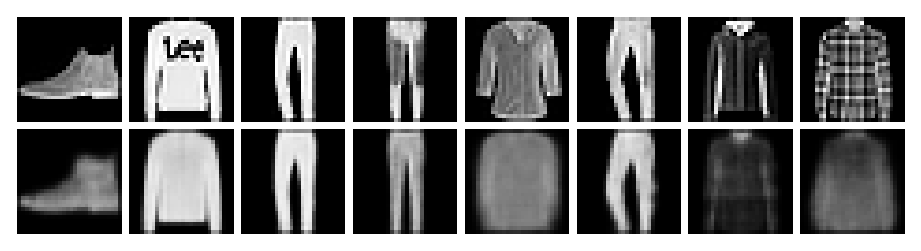

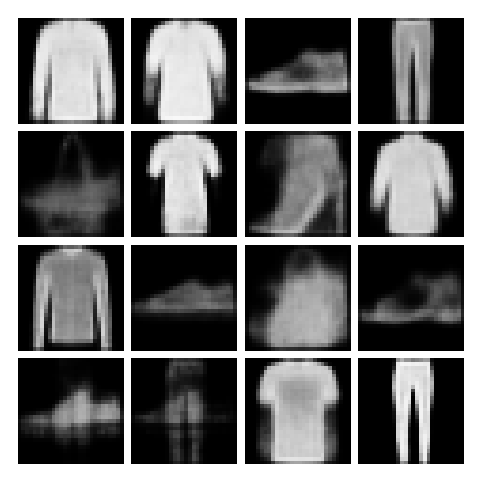

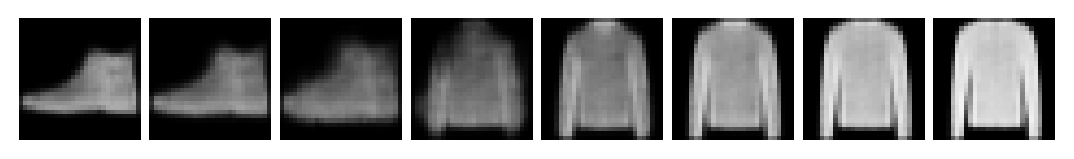

In [11]:
show_reconstructions(beta_model, test_loader, device)
show_samples(beta_model, device)
interpolate(beta_model, test_loader, device)

The scheduling function is important because a fixed `beta=4` from the first iteration and a run that ends near `beta=4` after a warm-up are not the same optimization problem. In the first case, the optimizer may shut down the **latent channel** before it ever becomes useful. In the second case, the model first learns to communicate through $\boldsymbol{z}$ and only later tightens the information budget.

Taken together, `beta-VAE`, `KL` annealing, and `**free bits**` show that VAE design is not only about the existence of a latent variable. It is also about how much information is allowed to pass through the **latent channel** and when that information becomes expensive.

## VQ-VAE and Discrete Latent Spaces

The second major branch of VAE variants changes something more radical than the information-control family. A `beta-VAE`, **KL annealing**, and **free bits** still keep the same basic object: an encoder produces the parameters of a continuous approximate posterior, usually a Gaussian distribution, and generation starts by sampling a continuous latent vector from a simple prior. A `VQ-VAE`, introduced in {cite}`oord2017vqvae`, changes the type of latent representation itself. The encoder does not output the mean and variance of a Gaussian posterior. It outputs a spatial grid of vectors, and each vector is replaced by the closest element of a learned finite dictionary, usually called a codebook.

This change is motivated by a limitation that appears repeatedly in vanilla VAEs. The decoder is trained through a **reconstruction term**, while the encoder is regularized toward a simple prior. If the decoder is expressive and the **KL pressure** is strong, the model can learn to ignore part of the **latent channel**. If the **latent channel** is used only weakly, the decoder tends to average over several plausible reconstructions, and the resulting images can look smooth. The problem is not simply that the latent variable is continuous. The problem is that a simple continuous prior, a powerful decoder, and a pixelwise likelihood can make the latent representation too cheap to ignore and too smooth to represent sharply separated alternatives.

The intuitive idea of `VQ-VAE` is to force the latent representation to choose symbols. Instead of saying that an image is represented by a point in a smooth Gaussian cloud, the model says that each spatial location in the image is represented by one entry from a learned visual vocabulary. For Fashion MNIST, one code may become useful for dark background regions, another for shoe contours, another for smooth fabric interiors, and another for high-curvature boundaries. These meanings are not assigned manually. They emerge because the encoder, codebook, and decoder are trained together.

Mathematically, let the encoder produce

$$
\boldsymbol{z}_e(\boldsymbol{x}) \in \mathbb{R}^{H' \times W' \times D}.
$$

At each spatial location $(i,j)$, the encoder vector $\boldsymbol{z}_{e,i,j}(\boldsymbol{x}) \in \mathbb{R}^D$ is quantized to the closest codebook vector among

$$
\mathcal{E} = \{\boldsymbol{e}_1,\ldots,\boldsymbol{e}_K\}, \qquad \boldsymbol{e}_k \in \mathbb{R}^D.
$$

The discrete index is

$$
k_{i,j}(\boldsymbol{x})
= \arg\min_{k \in \{1,\ldots,K\}}
\left\|\boldsymbol{z}_{e,i,j}(\boldsymbol{x}) - \boldsymbol{e}_k\right\|_2^2,
$$

and the quantized latent vector is

$$
\boldsymbol{z}_{q,i,j}(\boldsymbol{x}) = \boldsymbol{e}_{k_{i,j}(\boldsymbol{x})}.
$$

The decoder receives $\boldsymbol{z}_q(\boldsymbol{x})$, not $\boldsymbol{z}_e(\boldsymbol{x})$. This is the central mechanism. The continuous encoder output is only an intermediate object used to decide which discrete code should be selected. The image is reconstructed from the selected codebook entries.

### The Quantization Step and the Straight-Through Estimator

The nearest-neighbor operation is the reason `VQ-VAE` is conceptually different from a Gaussian VAE, but it is also the main optimization difficulty. The map

$$
\boldsymbol{z}_{e,i,j}(\boldsymbol{x}) \mapsto
\arg\min_k \left\|\boldsymbol{z}_{e,i,j}(\boldsymbol{x}) - \boldsymbol{e}_k\right\|_2^2
$$

is piecewise constant. If the encoder vector moves a little but remains closest to the same codebook vector, the selected index does not change. Therefore, the true derivative of the discrete index with respect to the encoder output is zero almost everywhere and undefined at the boundaries between Voronoi cells. A naive backpropagation through the argmin would not give a useful learning signal to the encoder.

`VQ-VAE` solves this with the **straight-through estimator**. In the forward pass, the decoder sees the quantized vector $\boldsymbol{z}_q$. In the backward pass, the gradient of the reconstruction loss is copied from $\boldsymbol{z}_q$ to $\boldsymbol{z}_e$ as if the quantization operation were the identity map. In code, this appears as

```python
z_q = z_e + (z_q - z_e).detach()
```

The value of this tensor is still the quantized vector, because the term inside `detach()` contributes $\boldsymbol{z}_q - \boldsymbol{z}_e$ in the forward pass. However, the derivative with respect to $\boldsymbol{z}_e$ is the derivative of the identity term. This is a biased gradient estimator, not an exact derivative. Its value is pragmatic: it lets the encoder receive a reconstruction gradient while preserving the discrete bottleneck in the forward computation.

```{figure} ../assets/images/VQ-VAE_diagram.png
:width: 66%
:align: center

The working mechanism of VQ-VAE.
```

The training objective has three parts. If $D_\theta$ is the decoder, the **reconstruction term** is

$$
\mathcal{L}_{rec}
= - \log p_\theta(\boldsymbol{x} | \boldsymbol{z}_q(\boldsymbol{x})).
$$

The **codebook loss** moves the selected embedding vectors toward the encoder outputs:

$$
\mathcal{L}_{codebook}
=
\left\|
\operatorname{sg}\left[\boldsymbol{z}_e(\boldsymbol{x})\right]
- \boldsymbol{z}_q(\boldsymbol{x})
\right\|_2^2.
$$

The stop-gradient operator $\operatorname{sg}[\cdot]$ means that this term updates the codebook but not the encoder. The **commitment loss** moves the encoder outputs toward the selected embeddings:

$$
\mathcal{L}_{commit}
=
\left\|
\boldsymbol{z}_e(\boldsymbol{x})
- \operatorname{sg}\left[\boldsymbol{z}_q(\boldsymbol{x})\right]
\right\|_2^2.
$$

The full loss used in the implementation is

$$
\mathcal{L}_{VQ}
=
\mathcal{L}_{rec}
+ \mathcal{L}_{codebook}
+ \beta_{commit}\mathcal{L}_{commit}.
$$

The commitment term is not a cosmetic detail. Without it, the encoder can keep moving its outputs around the continuous space while the codebook chases them. The quantizer then becomes unstable, codes can be used inconsistently, and the decoder receives a moving symbolic language. The commitment term asks the encoder to commit to the vocabulary it is learning to use.

A complete `VQ-VAE` generative model has two stages. The first stage is an autoencoding stage: it learns the encoder, codebook, and decoder. This stage tells us how to convert an image into a grid of discrete indices and how to decode such a grid back into an image. However, this alone is not enough for unconditional generation. It only gives a tokenizer and a detokenizer. To generate new images, we still need to know which grids of indices are likely.

This distinction is crucial. If we sample each code independently from its marginal frequency, we preserve only how often each code appears. We destroy spatial dependence. A code that often appears near the boundary of a shoe may be sampled in the middle of the background. A code that represents a local texture may be placed next to incompatible neighboring codes. The decoder will still produce an image, but the image will usually be poor because the latent grid is not a plausible encoded Fashion MNIST image.

The second stage therefore learns a prior over code grids:

$$
p_\psi(\boldsymbol{k})
=
\prod_{i,j}
p_\psi(k_{i,j} | k_{<i,j}),
$$

where $\boldsymbol{k}$ is the grid of discrete indices and $k_{<i,j}$ denotes the previously generated positions in raster order. In the code below this prior is a small **PixelCNN**. The masks in the convolutional layers enforce the autoregressive rule: when predicting the code at one location, the network can only use earlier locations. Sampling then proceeds one position at a time. The **PixelCNN** samples the code grid, and the `VQ-VAE` decoder maps the sampled codebook vectors into an image.

```{figure} ../assets/images/VQ-VAE_sampling.png
:width: 66%
:align: center

Sampling VQ-VAE using **PixelCNN**.
```


This also clarifies why `VQ-VAE` can solve some vanilla VAE weaknesses but creates new failure modes. It reduces the pressure to match every approximate posterior to a simple **Gaussian prior**, because the representation is discrete and the prior can be learned after the tokenizer. It can avoid some smooth averaging because the decoder sees selected visual tokens rather than noisy Gaussian samples. But **codebook collapse** can still happen: if only a few codebook entries are used, the discrete vocabulary is mostly dead. Prior mismatch can also still happen: if the **PixelCNN** prior learns the code-grid distribution poorly, reconstructions may look good while unconditional samples look bad. The code therefore reports code usage and trains the prior on codes produced by the same trained `VQ-VAE`.

The implementation below follows this two-stage structure. First, the `VQ-VAE` learns a discrete latent vocabulary and a decoder. Second, the training set is encoded into grids of code indices. Third, a **PixelCNN** prior is trained over those grids. Sampling independent code indices from a histogram is intentionally avoided because it removes the spatial structure that the decoder expects.

```{admonition} VQ-VAE in one line
:class: note

The encoder produces continuous vectors, the quantizer replaces them with nearest codebook entries, the decoder reconstructs from those discrete codes, and a separate prior learns which code grids are plausible.
```

In [12]:
class VectorQuantizer(nn.Module):
    def __init__(self, num_embeddings=128, embedding_dim=64, commitment_cost=0.1):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.commitment_cost = commitment_cost
        self.codebook = nn.Embedding(num_embeddings, embedding_dim)
        nn.init.normal_(self.codebook.weight, mean=0.0, std=0.5)

    def forward(self, z_e):
        flat = z_e.permute(0, 2, 3, 1).contiguous().view(-1, self.embedding_dim)
        distances = (
            flat.pow(2).sum(1, keepdim=True)
            - 2 * flat @ self.codebook.weight.t()
            + self.codebook.weight.pow(2).sum(1)
        )
        indices = distances.argmin(dim=1)
        z_q = self.codebook(indices).view(z_e.size(0), z_e.size(2), z_e.size(3), self.embedding_dim)
        z_q = z_q.permute(0, 3, 1, 2).contiguous()

        codebook_loss = F.mse_loss(z_e.detach(), z_q)
        commitment_loss = F.mse_loss(z_e, z_q.detach())
        loss = codebook_loss + self.commitment_cost * commitment_loss

        encodings = F.one_hot(indices, self.num_embeddings).float()
        avg_probs = encodings.mean(dim=0)
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))

        z_q = z_e + (z_q - z_e).detach()
        return z_q, loss, indices.view(z_e.size(0), z_e.size(2), z_e.size(3)), perplexity


class VQResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.Conv2d(channels, channels, kernel_size=1),
        )

    def forward(self, x):
        return F.relu(x + self.net(x), inplace=True)


class VQVAE(nn.Module):
    def __init__(self, embedding_dim=64, num_embeddings=128, base_channels=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, base_channels, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            VQResidualBlock(base_channels),
            nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            VQResidualBlock(base_channels * 2),
            nn.Conv2d(base_channels * 2, embedding_dim, kernel_size=1),
        )
        self.quantizer = VectorQuantizer(num_embeddings=num_embeddings, embedding_dim=embedding_dim)
        self.decoder = nn.Sequential(
            nn.Conv2d(embedding_dim, base_channels * 2, kernel_size=3, padding=1),
            nn.ReLU(True),
            VQResidualBlock(base_channels * 2),
            nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            VQResidualBlock(base_channels),
            nn.ConvTranspose2d(base_channels, 1, kernel_size=4, stride=2, padding=1),
        )

    def forward(self, x):
        z_e = self.encoder(x)
        z_q, vq_loss, indices, perplexity = self.quantizer(z_e)
        logits = self.decoder(z_q)
        return logits, vq_loss, indices, perplexity


class MaskedConv2d(nn.Conv2d):
    def __init__(self, mask_type, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.register_buffer("mask", torch.ones_like(self.weight))
        _, _, h, w = self.weight.shape
        self.mask[:, :, h // 2, w // 2 + (mask_type == "B") :] = 0
        self.mask[:, :, h // 2 + 1 :] = 0

    def forward(self, x):
        return F.conv2d(
            x,
            self.weight * self.mask,
            self.bias,
            self.stride,
            self.padding,
            self.dilation,
            self.groups,
        )


class PixelCNNPrior(nn.Module):
    def __init__(self, num_embeddings, hidden_channels=192, num_layers=6):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings, hidden_channels)
        layers = [MaskedConv2d("A", hidden_channels, hidden_channels, kernel_size=5, padding=2), nn.ReLU(True)]
        for _ in range(num_layers - 1):
            layers += [MaskedConv2d("B", hidden_channels, hidden_channels, kernel_size=3, padding=1), nn.ReLU(True)]
        layers.append(nn.Conv2d(hidden_channels, num_embeddings, kernel_size=1))
        self.net = nn.Sequential(*layers)

    def forward(self, indices):
        x = self.embedding(indices).permute(0, 3, 1, 2).contiguous()
        return self.net(x)


@torch.no_grad()
def encode_dataset_to_indices(model, loader, device):
    model.eval()
    all_indices = []
    for x, _ in tqdm(loader, desc="encode codes", leave=False):
        x = x.to(device)
        _, _, indices, _ = model(x)
        all_indices.append(indices.cpu())
    return torch.cat(all_indices, dim=0)


vqvae = VQVAE(embedding_dim=64, num_embeddings=128, base_channels=64).to(device)
vq_optimizer = torch.optim.Adam(vqvae.parameters(), lr=2e-4)
vq_epochs = 80
for epoch in tqdm(range(vq_epochs), desc="VQ-VAE epochs"):
    vqvae.train()
    running = 0.0
    running_recon = 0.0
    running_vq = 0.0
    running_perplexity = 0.0
    for x, _ in tqdm(train_loader, desc="VQ train", leave=False):
        x = x.to(device)
        vq_optimizer.zero_grad()
        logits, vq_loss, _, perplexity = vqvae(x)
        recon = F.binary_cross_entropy_with_logits(logits, x, reduction="mean")
        loss = recon + vq_loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(vqvae.parameters(), max_norm=1.0)
        vq_optimizer.step()
        running += loss.item()
        running_recon += recon.item()
        running_vq += vq_loss.item()
        running_perplexity += perplexity.item()
    print(
        f"Epoch {epoch + 1:02d} | VQ-VAE loss: {running / len(train_loader):.4f} | "
        f"recon: {running_recon / len(train_loader):.4f} | "
        f"vq: {running_vq / len(train_loader):.4f} | "
        f"perplexity: {running_perplexity / len(train_loader):.1f}"
    )


train_code_indices = encode_dataset_to_indices(vqvae, train_loader, device)
test_code_indices = encode_dataset_to_indices(vqvae, test_loader, device)
code_height, code_width = train_code_indices.shape[1:]

prior_train_loader = DataLoader(
    TensorDataset(train_code_indices.long()),
    batch_size=256,
    shuffle=True,
    num_workers=0,
)
prior_test_loader = DataLoader(
    TensorDataset(test_code_indices.long()),
    batch_size=256,
    shuffle=False,
    num_workers=0,
)

pixel_prior = PixelCNNPrior(vqvae.quantizer.num_embeddings).to(device)
prior_optimizer = torch.optim.Adam(pixel_prior.parameters(), lr=2e-4)
prior_epochs = 60
for epoch in tqdm(range(prior_epochs), desc="PixelCNN prior epochs"):
    pixel_prior.train()
    running = 0.0
    for (indices,) in tqdm(prior_train_loader, desc="prior train", leave=False):
        indices = indices.to(device)
        prior_optimizer.zero_grad()
        logits = pixel_prior(indices)
        loss = F.cross_entropy(logits, indices)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(pixel_prior.parameters(), max_norm=1.0)
        prior_optimizer.step()
        running += loss.item()
    prior_eval = 0.0
    pixel_prior.eval()
    for (indices,) in prior_test_loader:
        indices = indices.to(device)
        logits = pixel_prior(indices)
        prior_eval += F.cross_entropy(logits, indices).item()
    prior_eval /= len(prior_test_loader)
    print(f"Epoch {epoch + 1:02d} | prior nll: {running / len(prior_train_loader):.4f} | val nll: {prior_eval:.4f}")


@torch.no_grad()
def sample_vqvae_with_prior(model, prior, n=16, temperature=0.85, top_k=40, visualize=False):
    model.eval()
    prior.eval()
    indices = torch.zeros(n, code_height, code_width, dtype=torch.long, device=device)
    for row in range(code_height):
        for col in range(code_width):
            logits = prior(indices)[:, :, row, col] / temperature
            if top_k is not None:
                values, choices = logits.topk(k=min(top_k, logits.size(1)), dim=1)
                probs = torch.softmax(values, dim=1)
                selected = torch.multinomial(probs, num_samples=1)
                indices[:, row, col] = choices.gather(1, selected).squeeze(1)
            else:
                probs = torch.softmax(logits, dim=1)
                indices[:, row, col] = torch.multinomial(probs, num_samples=1).squeeze(1)
    z_q = model.quantizer.codebook(indices.view(-1)).view(
        n, code_height, code_width, model.quantizer.embedding_dim
    )
    z_q = z_q.permute(0, 3, 1, 2).contiguous()
    logits = model.decoder(z_q)
    samples = torch.sigmoid(logits)
    if visualize:
        image = utils.make_grid(samples.cpu(), nrow=4, pad_value=1.0)
        plt.figure(figsize=(6, 6))
        plt.imshow(image.permute(1, 2, 0), cmap="gray")
        plt.axis("off")
        plt.show()
    return samples

VQ-VAE epochs:   0%|          | 0/80 [00:00<?, ?it/s]

VQ train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 01 | VQ-VAE loss: 1.1605 | recon: 0.3588 | vq: 0.8017 | perplexity: 2.8


VQ train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 02 | VQ-VAE loss: 0.7199 | recon: 0.2955 | vq: 0.4244 | perplexity: 5.0


...

Epoch 58 | prior nll: 1.5850 | val nll: 1.6586


prior train:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 59 | prior nll: 1.5828 | val nll: 1.6600


prior train:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 60 | prior nll: 1.5812 | val nll: 1.6584


In [13]:
@torch.no_grad()
def collect_code_statistics(model, loader, device):
    counts = torch.zeros(model.quantizer.num_embeddings, device=device)
    model.eval()
    for x, _ in tqdm(loader, desc="code usage", leave=False):
        x = x.to(device)
        _, _, indices, _ = model(x)
        counts += torch.bincount(indices.reshape(-1), minlength=model.quantizer.num_embeddings).float()
    probs = counts / counts.sum()
    active_codes = int((counts > 0).sum().item())
    usage_perplexity = torch.exp(-torch.sum(probs * torch.log(probs + 1e-10))).item()
    return {"active_codes": active_codes, "usage_perplexity": usage_perplexity}


vq_code_stats = collect_code_statistics(vqvae, train_loader, device)
print(vq_code_stats)

code usage:   0%|          | 0/469 [00:00<?, ?it/s]

{'active_codes': 37, 'usage_perplexity': 21.857250213623047}


Once the prior is trained, `VQ-VAE` becomes a real two-stage generative pipeline rather than just an autoencoding tokenizer. The first stage learns the map

$$
\boldsymbol{x}
\longmapsto
\boldsymbol{k}(\boldsymbol{x})
\longmapsto
\hat{\boldsymbol{x}},
$$

where $\boldsymbol{k}(\boldsymbol{x})$ is a grid of discrete code indices. The second stage learns how to sample plausible $\boldsymbol{k}$ grids without seeing the original image. This separation exposes two different questions that are entangled in a vanilla VAE. The first question is representation learning: can the model describe an image with a compact latent object? The second question is generative modeling: can the model sample latent objects that look like the ones produced by real images?

The code-usage diagnostic is included for the same reason that KL diagnostics are included for Gaussian VAEs. In a Gaussian VAE, a latent coordinate can become inactive when its approximate posterior remains close to the prior for every input. In `VQ-VAE`, a codebook vector can become inactive when no encoder output selects it. Both cases are forms of unused latent capacity. They are not mathematically identical, but they express the same practical warning: the architecture may contain a large **latent space** while the trained model uses only a small part of it.

The prior diagnostic is equally important. Good reconstructions do not imply good samples. **Reconstruction**s use code grids obtained from real images, while generation uses code grids sampled from the learned prior. If the **PixelCNN** prior is weak, the sampled grids will not resemble encoded training grids, and the decoder will turn implausible latent syntax into implausible images. The implementation therefore uses a single trained `VQ-VAE`, measures code usage, trains the **PixelCNN** on that same model's codes, and samples with a mildly tempered top-k distribution to avoid very unlikely code choices.

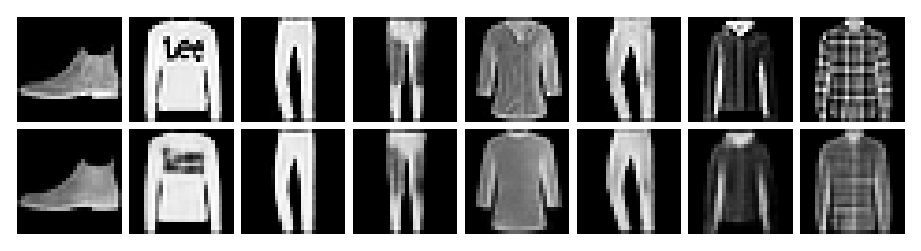

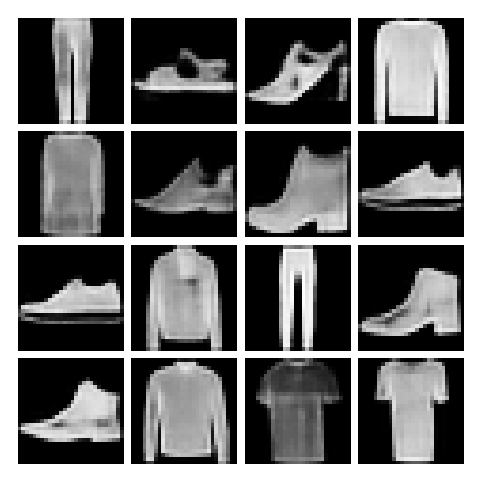

tensor([[[[1.8388e-06, 8.7527e-07, 1.6401e-06,  ..., 4.9438e-08,
           5.1605e-07, 2.6850e-07],
          [1.9706e-07, 2.4110e-07, 1.3144e-06,  ..., 1.4650e-08,
           2.2133e-07, 8.7189e-08],
          [4.5099e-07, 3.7487e-07, 1.0401e-06,  ..., 5.9686e-09,
           1.1103e-06, 4.4317e-08],
          ...,
          [2.2583e-06, 4.8267e-07, 4.0752e-06,  ..., 2.3749e-08,
           2.5511e-07, 1.7993e-08],
          [3.1515e-07, 9.4032e-08, 3.2839e-07,  ..., 1.8399e-07,
           5.6140e-07, 7.0167e-08],
          [1.9027e-06, 4.5928e-07, 1.6511e-06,  ..., 5.1731e-07,
           2.2195e-06, 2.3041e-06]]],


        [[[3.1636e-07, 1.0489e-08, 2.9412e-08,  ..., 5.9324e-09,
           8.1758e-08, 2.4147e-07],
          [7.9983e-07, 9.3212e-08, 5.4065e-08,  ..., 2.5230e-08,
           7.3933e-07, 4.6091e-07],
          [8.6812e-08, 2.2255e-08, 1.9605e-06,  ..., 4.1074e-08,
           1.9353e-06, 9.7186e-07],
          ...,
          [3.9454e-05, 1.0206e-05, 5.5081e-07,  ..., 2.77

In [14]:
@torch.no_grad()
def show_vqvae_reconstructions(model, loader, device, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)
    logits, _, _, _ = model(x)
    recon = torch.sigmoid(logits).cpu()
    grid = utils.make_grid(torch.cat([x.cpu(), recon], dim=0), nrow=n, pad_value=1.0)
    plt.figure(figsize=(1.5 * n, 3.0))
    plt.imshow(grid.permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.show()


show_vqvae_reconstructions(vqvae, test_loader, device)
sample_vqvae_with_prior(vqvae, pixel_prior, n=16, visualize=True)

## **Conditional VAEs** and the Move to Controlled **Generation**

The variants considered so far still model the unconditional data distribution $p_{gt}(\boldsymbol{x})$. A conditional VAE changes the question. Instead of asking the model to generate a plausible image with no further instruction, we ask it to generate a plausible image given side information $\boldsymbol{y}$. For Fashion MNIST, $\boldsymbol{y}$ is the class label. The model should generate an ankle boot when $\boldsymbol{y}$ says ankle boot, a shirt when $\boldsymbol{y}$ says shirt, and so on. The remaining latent variable should represent variability inside the chosen class: style, thickness, pose, local shape, and other factors not specified by the label.

The conditional generative model is

$$
p_\theta(\boldsymbol{x},\boldsymbol{z}|\boldsymbol{y})
=
p(\boldsymbol{z}|\boldsymbol{y})
p_\theta(\boldsymbol{x}|\boldsymbol{z},\boldsymbol{y}).
$$

In the simplest implementation, the prior is still $p(\boldsymbol{z}|\boldsymbol{y}) = \mathcal{N}(\boldsymbol{0},\boldsymbol{I})$, so the label changes only the encoder and decoder inputs. More expressive conditional VAEs can also learn a label-dependent prior. The approximate posterior becomes

$$
q_\phi(\boldsymbol{z}|\boldsymbol{x},\boldsymbol{y}),
$$

and the conditional ELBO is

$$
\log p_\theta(\boldsymbol{x}|\boldsymbol{y})
\geq
\mathbb{E}_{q_\phi(\boldsymbol{z}|\boldsymbol{x},\boldsymbol{y})}
\left[
\log p_\theta(\boldsymbol{x}|\boldsymbol{z},\boldsymbol{y})
\right]
-
D_{KL}\left(
q_\phi(\boldsymbol{z}|\boldsymbol{x},\boldsymbol{y})
\| p(\boldsymbol{z}|\boldsymbol{y})
\right).
$$

This is the same variational argument as before, but applied to a conditional likelihood. The label is not an afterthought added to the generated image. It is part of the probabilistic model. The decoder is explicitly trained to explain $\boldsymbol{x}$ using both $\boldsymbol{z}$ and $\boldsymbol{y}$, while the encoder learns the posterior over residual factors that remain uncertain after observing the label.

```{figure} ../assets/images/cVAE_diagram.png
:width: 66%
:align: center

The mechanism of Conditional VAE.
```

From the motivational perspective, a conditional VAE separates **what should be controlled** from **what should remain random**. In an unconditional VAE, class identity and within-class style compete for the same latent capacity. Some latent coordinates may encode whether the image is a sandal or a coat, while others encode details inside the class. In a conditional VAE, the class is provided directly. This frees the latent variable to focus on intra-class variation. This is why conditional generation is often visually cleaner than unconditional generation with the same network size.

This also addresses a different limitation of vanilla VAEs. The vanilla model may generate a plausible image, but it gives the user little control over what kind of image appears. **Conditional VAEs**, introduced in the broader conditional deep generative modeling literature {cite}`sohn2015cvae`, turn generation into an input-output problem: choose a condition, sample a latent vector, decode. The cost is that the model now depends on the availability and quality of the conditioning variable. If the labels are noisy, incomplete, or too coarse, the conditional model inherits those limitations.

In [15]:
num_classes = 10


class ConditionalVAE(nn.Module):
    def __init__(self, latent_dim=32, base_channels=32, num_classes=10, label_dim=16):
        super().__init__()
        self.label_embed = nn.Embedding(num_classes, label_dim)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, base_channels, kernel_size=4, stride=2, padding=1),
            nn.SiLU(),
            nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1),
            nn.SiLU(),
            nn.Flatten(),
        )
        encoded_dim = base_channels * 2 * 7 * 7
        self.mu_head = nn.Linear(encoded_dim + label_dim, latent_dim)
        self.logvar_head = nn.Linear(encoded_dim + label_dim, latent_dim)
        self.decoder_input = nn.Linear(latent_dim + label_dim, base_channels * 4 * 7 * 7)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (base_channels * 4, 7, 7)),
            nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=4, stride=2, padding=1),
            nn.SiLU(),
            nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1),
            nn.SiLU(),
            nn.Conv2d(base_channels, 1, kernel_size=3, padding=1),
        )

    def encode(self, x, y):
        h = self.encoder(x)
        y_embed = self.label_embed(y)
        h = torch.cat([h, y_embed], dim=1)
        return self.mu_head(h), self.logvar_head(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z, y):
        y_embed = self.label_embed(y)
        h = self.decoder_input(torch.cat([z, y_embed], dim=1))
        return self.decoder(h)

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z, y)
        return logits, mu, logvar


@torch.no_grad()
def sample_cvae(model, class_id, n, device):
    model.eval()
    labels = torch.full((n,), class_id, device=device, dtype=torch.long)
    z = torch.randn(n, latent_dim, device=device)
    logits = model.decode(z, labels)
    return torch.sigmoid(logits)


@torch.no_grad()
def sample_cvae_from_labels(model, labels, device):
    model.eval()
    z = torch.randn(labels.size(0), latent_dim, device=device)
    logits = model.decode(z, labels)
    return torch.sigmoid(logits)


In [16]:
def train_conditional_vae_epoch(model, loader, optimizer, device, beta=1.0, free_bits=0.0):
    model.train()
    total_loss = 0.0
    total_kl = 0.0

    for x, y in tqdm(loader, desc="cVAE train", leave=False):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits, mu, logvar = model(x, y)
        loss, _, kl = beta_vae_loss(x, logits, mu, logvar, beta=beta, free_bits=free_bits)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_kl += kl.item()

    n = len(loader.dataset)
    return {"loss": total_loss / n, "kl": total_kl / n}


@torch.no_grad()
def evaluate_conditional_vae(model, loader, device, beta=1.0, free_bits=0.0):
    model.eval()
    total_loss = 0.0
    total_kl = 0.0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits, mu, logvar = model(x, y)
        loss, _, kl = beta_vae_loss(x, logits, mu, logvar, beta=beta, free_bits=free_bits)
        total_loss += loss.item()
        total_kl += kl.item()

    n = len(loader.dataset)
    return {"loss": total_loss / n, "kl": total_kl / n}


conditional_epochs = 50
cvae = ConditionalVAE(
    latent_dim=latent_dim,
    base_channels=base_channels,
    num_classes=num_classes,
).to(device)
cvae_optimizer = torch.optim.Adam(cvae.parameters(), lr=lr)
conditional_history = {"train_loss": [], "val_loss": [], "beta": []}

for epoch in tqdm(range(conditional_epochs), desc="cVAE epochs"):
    beta_t = linear_beta_schedule(epoch, conditional_epochs, start=0.0, stop=1.0, warmup_fraction=0.4)
    train_stats = train_conditional_vae_epoch(cvae, train_loader, cvae_optimizer, device, beta=beta_t, free_bits=0.1)
    val_stats = evaluate_conditional_vae(cvae, test_loader, device, beta=beta_t, free_bits=0.1)

    conditional_history["train_loss"].append(train_stats["loss"])
    conditional_history["val_loss"].append(val_stats["loss"])
    conditional_history["beta"].append(beta_t)

    print(
        f"Epoch {epoch + 1:02d} | beta: {beta_t:.2f} | "
        f"train loss: {train_stats['loss']:.4f} | val loss: {val_stats['loss']:.4f}"
    )


cVAE epochs:   0%|          | 0/50 [00:00<?, ?it/s]

cVAE train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 01 | beta: 0.00 | train loss: 289.9086 | val loss: 239.6424


cVAE train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 02 | beta: 0.05 | train loss: 237.8366 | val loss: 233.5603


...

Epoch 48 | beta: 1.00 | train loss: 234.1784 | val loss: 236.1391


cVAE train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 49 | beta: 1.00 | train loss: 234.1319 | val loss: 236.1154


cVAE train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 50 | beta: 1.00 | train loss: 234.0209 | val loss: 236.0109


At this point, the label is not a decorative extra input. It changes the generative question from “draw any fashion item” to “draw a fashion item of the requested class.” The latent variable still matters, but its role changes: it no longer explains *which class* the object belongs to, because that part is already specified by the condition. Instead, it models the **residual uncertainty** *inside* the class.

This is why conditioning is so important conceptually. Once a condition is given, generation becomes a controlled mapping from a coarse semantic request plus latent noise to a concrete sample. In tiny form, that is already the same idea that later appears in text-guided image generation: the condition determines the semantic target, while the latent randomness governs the particular realization.


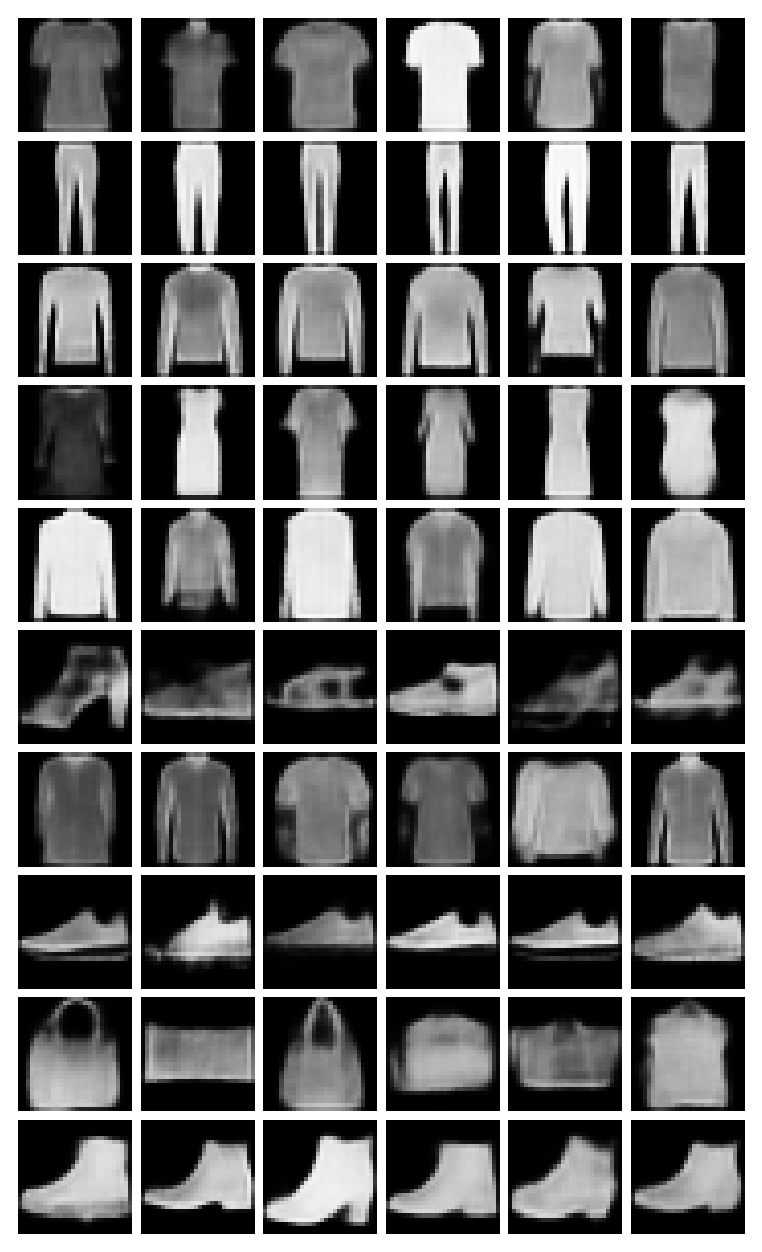

row 0: T-shirt/top
row 1: Trouser
row 2: Pullover
row 3: Dress
row 4: Coat
row 5: Sandal
row 6: Shirt
row 7: Sneaker
row 8: Bag
row 9: Ankle boot


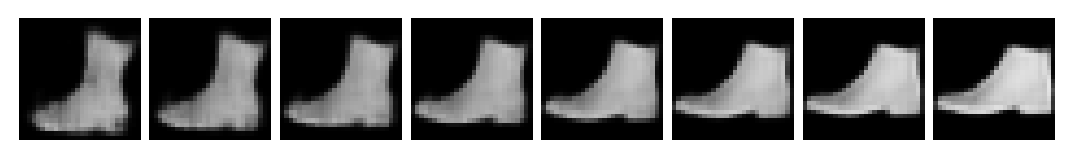

class-conditioned interpolation: Ankle boot


In [17]:
@torch.no_grad()
def show_cvae_class_samples(model, class_names, device, n_per_class=6):
    model.eval()
    rows = []
    for class_id, _ in enumerate(class_names):
        labels = torch.full((n_per_class,), class_id, device=device, dtype=torch.long)
        z = torch.randn(n_per_class, latent_dim, device=device)
        logits = model.decode(z, labels)
        rows.append(torch.sigmoid(logits).cpu())

    image = utils.make_grid(torch.cat(rows, dim=0), nrow=n_per_class, pad_value=1.0)
    plt.figure(figsize=(1.6 * n_per_class, 1.6 * len(class_names)))
    plt.imshow(image.permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.show()

    for class_id, name in enumerate(class_names):
        print(f"row {class_id}: {name}")


@torch.no_grad()
def interpolate_cvae_with_fixed_class(model, class_id, class_name, device, steps=8):
    model.eval()
    labels = torch.full((2,), class_id, device=device, dtype=torch.long)
    z0 = torch.randn(1, latent_dim, device=device)
    z1 = torch.randn(1, latent_dim, device=device)
    alphas = torch.linspace(0, 1, steps, device=device).view(-1, 1)
    z = (1 - alphas) * z0 + alphas * z1
    labels = torch.full((steps,), class_id, device=device, dtype=torch.long)
    logits = model.decode(z, labels)
    samples = torch.sigmoid(logits).cpu()
    image = utils.make_grid(samples, nrow=steps, pad_value=1.0)
    plt.figure(figsize=(1.7 * steps, 2.5))
    plt.imshow(image.permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.show()
    print(f"class-conditioned interpolation: {class_name}")


show_cvae_class_samples(cvae, train_dataset.classes, device, n_per_class=6)
interpolate_cvae_with_fixed_class(cvae, class_id=9, class_name=train_dataset.classes[9], device=device)

The expected qualitative result is now stronger than in the unconditional case. Each row should stay semantically tied to its class, while still showing variability across columns. For instance, the `Sandal` row should not collapse to a single repeated template, and it should not drift into `Sneaker` or `Ankle boot`. If that happens, the model is either undertrained or not using the conditioning signal effectively.

The interpolation experiment adds a second check. By fixing the class and moving only in **latent space**, we can ask whether the model learned a smooth **within-class manifold**. A good result should morph one boot into another boot, not silently wander into a different class. That is exactly the decomposition we want: the label controls the *semantic family*, and the latent variable controls the *instance-level variation* inside that family.


```{admonition} Conditional generation
:class: tip

The condition specifies what should be controlled. The latent variable models what should remain variable inside that condition.
```

This methodological separation between **condition information** and **residual uncertainty** is the main reason conditional generative models became central in image generation. The condition specifies the part of the image distribution that should be controlled. The latent variable models the part that should remain diverse. In the Fashion MNIST example the condition is only a class label, but the same principle later appears with text prompts, segmentation maps, low-resolution images, edge maps, and other forms of guidance.

The conditional VAE also gives a useful warning. Adding labels does not automatically solve every VAE limitation. A weak decoder can still produce blurry samples. A badly weighted **KL term** can still underuse the latent variable. A condition that is too informative can even make the latent variable less necessary, because the decoder may explain most variation from $\boldsymbol{y}$ alone. Therefore, the correct diagnostic question is not only whether the generated class is right. It is also whether samples within each class remain diverse and whether the latent variable actually controls meaningful residual variation.

## Shared FID/KID Evaluation With Cached Real Features

All qualitative experiments above can be run variant by variant. For **FID** and **KID**, however, it is more efficient to centralize the evaluation and cache the real-data features once. This keeps the comparison focused on the generators rather than on repeated metric bookkeeping.

The progress bars below are written with explicit totals. This avoids the confusing behavior where a real-feature pass appears to stop at about one fifth of the dataloader simply because the function intentionally uses only the first `num_real` images and exits early.

In [18]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance


def prepare_for_inception_metrics(images):
    if images.size(1) == 1:
        images = images.repeat(1, 3, 1, 1)
    return images.clamp(0.0, 1.0)


@torch.no_grad()
def build_cached_real_metrics(real_loader, device, num_real=1000, metric_batch_size=64):
    fid = FrechetInceptionDistance(feature=2048, normalize=True, reset_real_features=False).set_dtype(torch.float64).to(device)
    kid = KernelInceptionDistance(feature=2048, subsets=10, subset_size=100, normalize=True, reset_real_features=False).to(device)
    seen = 0
    pbar = tqdm(total=num_real, desc="real metric cache")
    for real_images, _ in real_loader:
        remaining = num_real - seen
        if remaining <= 0:
            break
        batch_n = min(metric_batch_size, remaining, real_images.size(0))
        real_images = real_images[:batch_n].to(device)
        real_images = prepare_for_inception_metrics(real_images)
        fid.update(real_images, real=True)
        kid.update(real_images, real=True)
        seen += batch_n
        pbar.update(batch_n)
    pbar.close()
    return fid, kid


@torch.no_grad()
def evaluate_with_cached_real(sample_fn, base_fid, base_kid, num_fake=1000, metric_batch_size=64):
    fid = copy.deepcopy(base_fid)
    kid = copy.deepcopy(base_kid)
    generated = 0
    pbar = tqdm(total=num_fake, desc="fake metric pass")
    while generated < num_fake:
        batch_n = min(metric_batch_size, num_fake - generated)
        fake_images = prepare_for_inception_metrics(sample_fn(batch_n).to(device))
        fid.update(fake_images, real=False)
        kid.update(fake_images, real=False)
        generated += batch_n
        pbar.update(batch_n)
    pbar.close()
    kid_mean, kid_std = kid.compute()
    return {"fid": fid.compute().item(), "kid_mean": kid_mean.item(), "kid_std": kid_std.item()}


base_fid, base_kid = build_cached_real_metrics(test_loader, device)

beta_scores = evaluate_with_cached_real(
    lambda n: torch.sigmoid(beta_model.decode(torch.randn(n, latent_dim, device=device))).view(-1, 1, 28, 28),
    base_fid, base_kid,
)
annealed_scores = evaluate_with_cached_real(
    lambda n: torch.sigmoid(annealed_model.decode(torch.randn(n, latent_dim, device=device))).view(-1, 1, 28, 28),
    base_fid, base_kid,
)
cvae_scores = evaluate_with_cached_real(
    lambda n: sample_cvae_from_labels(cvae, torch.randint(0, num_classes, (n,), device=device), device=device),
    base_fid, base_kid,
)
vq_scores = evaluate_with_cached_real(
    lambda n: sample_vqvae_with_prior(vqvae, pixel_prior, n=n),
    base_fid, base_kid,
)

print({"beta_vae": beta_scores, "annealed_vae": annealed_scores, "cvae": cvae_scores, "vqvae": vq_scores})

c:\Users\tivog\deep-generative-models\.venv\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


real metric cache:   0%|          | 0/1000 [00:00<?, ?it/s]

fake metric pass:   0%|          | 0/1000 [00:00<?, ?it/s]

fake metric pass:   0%|          | 0/1000 [00:00<?, ?it/s]

fake metric pass:   0%|          | 0/1000 [00:00<?, ?it/s]

fake metric pass:   0%|          | 0/1000 [00:00<?, ?it/s]

{'beta_vae': {'fid': 102.72027338741617, 'kid_mean': 0.06729691475629807, 'kid_std': 0.007766149006783962}, 'annealed_vae': {'fid': 82.82584312304093, 'kid_mean': 0.05955789238214493, 'kid_std': 0.009505385532975197}, 'cvae': {'fid': 72.32588698064956, 'kid_mean': 0.042409516870975494, 'kid_std': 0.004419077653437853}, 'vqvae': {'fid': 46.622274470146664, 'kid_mean': 0.017936063930392265, 'kid_std': 0.0042106108739972115}}


## What To Remember

The variants above should be read as targeted interventions on the vanilla VAE rather than as unrelated architectures. Information-control methods such as `beta-VAE`, **KL annealing**, and **free bits** modify the pressure exerted by the **KL term**, so they address balancing problems, dead **latent dimension**s, and **posterior collapse**. Discrete-latent methods such as `VQ-VAE` change the representation itself, replacing a continuous Gaussian bottleneck with a learned codebook and requiring a second-stage prior for good unconditional generation. **Conditional VAEs** change the generative question from "sample anything plausible" to "sample something plausible under this condition," which is the first step toward **controlled generation**.